In [13]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# import df_merged_istat_data_comuni_name 
df_merged_istat_data_comuni_name = pd.read_csv('../clean/cleaned_istat_data.csv')

# display the first 5 rows of the df_merged_istat_data_comuni_name dataframe
df_merged_istat_data_comuni_name.head()

,REF_AREA,TIME_PERIOD,KILLINJ,ROADACC,Comune,Superficie (Kmq),Popolazione residente,ROADACC_PER_CAPITA,ROADACC_PER_KM2
0,1001,2001,10,5,Agliè,13.1463,2585.0,0.001934,0.380335
1,1001,2002,10,5,Agliè,13.1463,2585.0,0.001934,0.380335
2,1001,2003,7,4,Agliè,13.1463,2585.0,0.001547,0.304268
3,1001,2004,13,9,Agliè,13.1463,2585.0,0.003482,0.684603
4,1001,2005,2,2,Agliè,13.1463,2585.0,0.000774,0.152134


In [15]:
# statistical information about the df_merged_istat_data_comuni_name dataframe
df_merged_istat_data_comuni_name.describe()

,REF_AREA,TIME_PERIOD,KILLINJ,ROADACC,Superficie (Kmq),Popolazione residente,ROADACC_PER_CAPITA,ROADACC_PER_KM2
count,175837.000000,175837.000000,175837.000000,175837.000000,175837.000000,1.758370e+05,175837.000000,175837.000000
mean,42340.008081,2012.492422,37.289336,26.204593,36.904188,7.686696e+03,0.002063,0.736585
std,30869.658499,6.872393,354.408698,268.049424,49.861733,4.299597e+04,0.002518,2.077052
min,1001.000000,2001.000000,0.000000,0.000000,0.122200,3.200000e+01,0.000000,0.000000
25%,16037.000000,2007.000000,1.000000,1.000000,11.230000,1.000000e+03,0.000488,0.027901
50%,35014.000000,2013.000000,6.000000,4.000000,21.759100,2.455000e+03,0.001567,0.168829
75%,68035.000000,2018.000000,20.000000,13.000000,42.636400,6.394000e+03,0.002856,0.609724
max,110010.000000,2024.000000,30514.000000,23135.000000,1288.187500,2.747290e+06,0.241497,99.176646


## Road Accidents Trend Over Time
This chart shows the total number of road accidents in Italy per year from 2001 to 2024.
There is a clear downward trend, likely due to improved road safety measures and stricter regulations.
The sharp drop in 2020 is attributable to the COVID-19 lockdown, which drastically reduced traffic.
After 2020, accidents started recovering towards pre-pandemic levels.

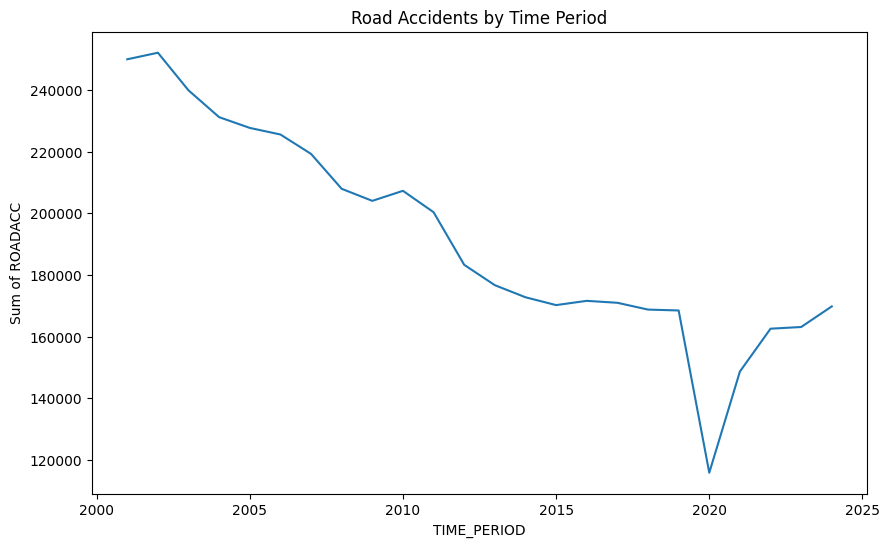

In [16]:
# group the df_merged_istat_data_comuni_name dataframe by 'TIME_PERIOD' and sum the 'ROADACC' column
df_merged_istat_data_comuni_name_groupby_time_period_sum_roadacc=df_merged_istat_data_comuni_name.groupby('TIME_PERIOD')['ROADACC'].sum().reset_index()

# visualize df_merged_istat_data_comuni_name_groupby_time_period_sum_roadacc using a line plot
plt.figure(figsize=(10,6))
plt.plot(df_merged_istat_data_comuni_name_groupby_time_period_sum_roadacc['TIME_PERIOD'], df_merged_istat_data_comuni_name_groupby_time_period_sum_roadacc['ROADACC'])
plt.xlabel('TIME_PERIOD')
plt.ylabel('Sum of ROADACC')
plt.title('Road Accidents by Time Period')
plt.show()

## Top 10 Municipalities by Total Road Accidents
This chart shows the municipalities with the highest total number of road accidents from 2001 to 2024.
Large cities like Roma and Milano dominate, simply due to their size and population.
However, this metric alone is misleading without considering population and surface area, which is why we also analyze accidents per capita and per km².

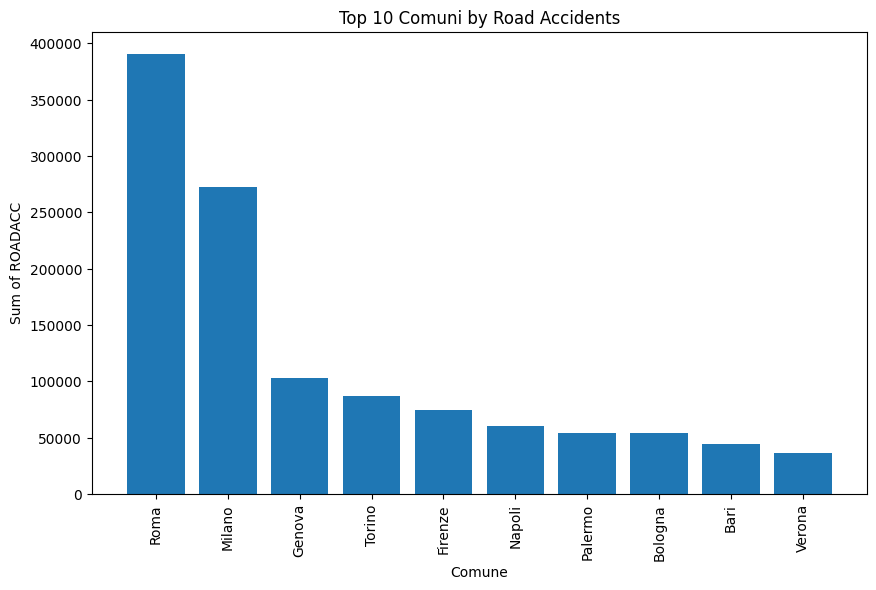

In [17]:
# group the df_merged_istat_data_comuni_name dataframe by 'Comune' and sum the 'ROADACC' column
df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc=df_merged_istat_data_comuni_name.groupby('Comune')['ROADACC'].sum().reset_index().sort_values(by='ROADACC', ascending=False).head(10)

# visualize df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc using a bar plot
plt.figure(figsize=(10,6))
plt.bar(df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc['Comune'], df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc['ROADACC'])
plt.xlabel('Comune')
plt.ylabel('Sum of ROADACC')
plt.title('Top 10 Comuni by Road Accidents')
plt.xticks(rotation=90)
plt.show()

## Top 10 Municipalities by Average Accidents per Capita
This chart shows the municipalities with the highest average annual accident rate relative to their population.
Small municipalities like Belforte Monferrato and Forte dei Marmi top the list, as they have few residents but high traffic volumes, especially during tourist seasons.

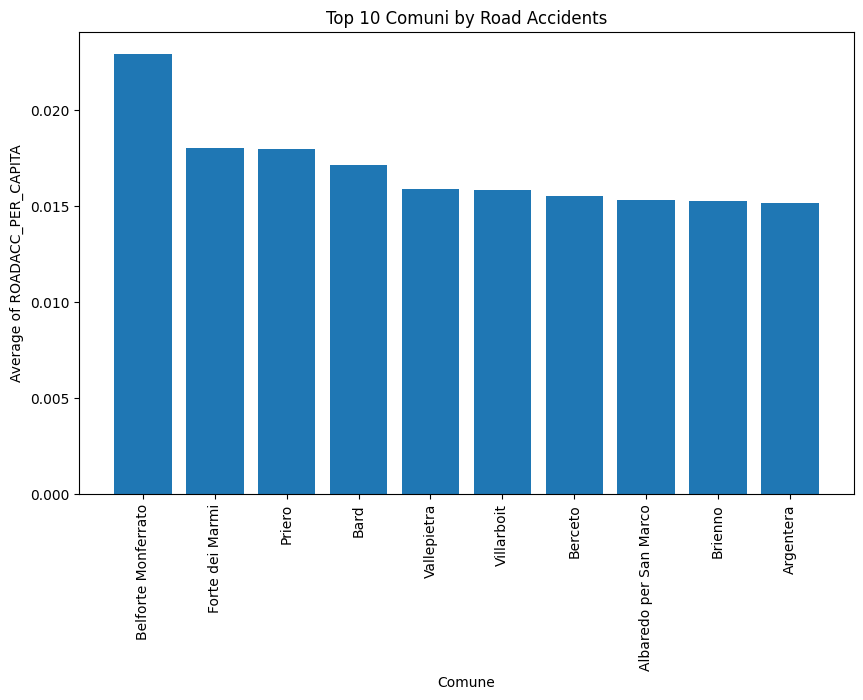

In [18]:
# group the df_merged_istat_data_comuni_name dataframe by 'Comune' and mean the 'ROADACC_PER_CAPITA' column
df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc_per_capita=df_merged_istat_data_comuni_name.groupby('Comune')['ROADACC_PER_CAPITA'].mean().reset_index().sort_values(by='ROADACC_PER_CAPITA', ascending=False).head(10)

# visualize df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc_per_capita using a bar plot
plt.figure(figsize=(10,6))
plt.bar(df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc_per_capita['Comune'], df_merged_istat_data_comuni_name_groupby_top_10_Comune_sum_roadacc_per_capita['ROADACC_PER_CAPITA'])
plt.xlabel('Comune')
plt.ylabel('Average of ROADACC_PER_CAPITA')
plt.title('Top 10 Comuni by Road Accidents')
plt.xticks(rotation=90)
plt.show()

## Top 10 Municipalities by Average Accidents per km²
This chart highlights the most dangerous municipalities in terms of accident density per square kilometer.
Milano leads by a wide margin, followed by densely urbanized municipalities in its metropolitan area.
This metric identifies areas where road infrastructure is under the most pressure.

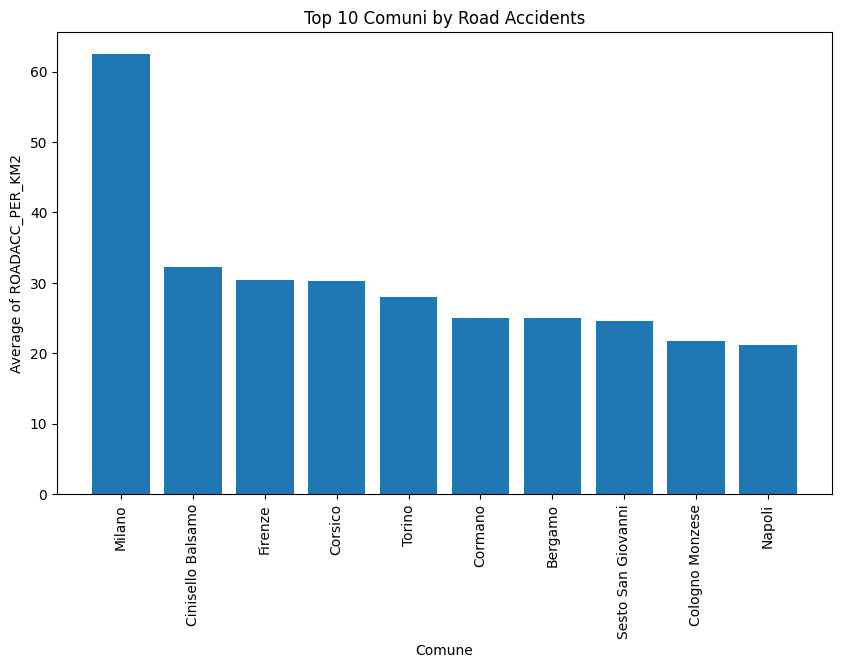

In [19]:
# group the df_merged_istat_data_comuni_name dataframe by 'Comune' and mean the 'ROADACC_PER_KM2' column
df_merged_istat_data_comuni_name_groupby_top_10_Comune_mean_roadacc_per_km2=df_merged_istat_data_comuni_name.groupby('Comune')['ROADACC_PER_KM2'].mean().reset_index().sort_values(by='ROADACC_PER_KM2', ascending=False).head(10)

# visualize df_merged_istat_data_comuni_name_groupby_top_10_Comune_mean_roadacc_per_km2 using a bar plot
plt.figure(figsize=(10,6))
plt.bar(df_merged_istat_data_comuni_name_groupby_top_10_Comune_mean_roadacc_per_km2['Comune'], df_merged_istat_data_comuni_name_groupby_top_10_Comune_mean_roadacc_per_km2['ROADACC_PER_KM2'])
plt.xlabel('Comune')
plt.ylabel('Average of ROADACC_PER_KM2')
plt.title('Top 10 Comuni by Road Accidents')
plt.xticks(rotation=90)
plt.show()